# Arabic reviews classification (RNN)

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

tf.random.set_seed(0)

I0000 00:00:1791560226.929417    9586 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791560226.966308    9586 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791560229.741150    9586 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
df = pd.read_csv('../assigment1/Dataset.tsv', sep='\t')
print(df.shape)
df['label'].value_counts()

(99999, 2)


label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64

## Preprocessing
same as assignment 1:
- remove urls, mentions, diacritics, tatweel
- normalize أ/إ/آ to ا, ى to ي, ة to ه
- collapse repeated letters (حلوووو to حلو)
- keep arabic letters only
- remove stopwords, but keep negations (لا, لم, ليس, ...)

In [3]:
stopwords = set('''في من الى علي عن هذا هذه ذلك تلك التي الذي الذين هو هي هم انا نحن انت
كان كانت ان او ثم مع كل بعد قبل حتي عند و ف ب ل ك اي اذا قد لقد هناك هنا كما بين'''.split())

def preprocess(text):
    text = re.sub(r'http\S+|www\.\S+|@\w+', ' ', text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652\u0670]', '', text)
    text = text.replace('ـ', '')
    text = re.sub('[إأآٱ]', 'ا', text)
    text = text.replace('ى', 'ي').replace('ة', 'ه').replace('ؤ', 'و').replace('ئ', 'ي')
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'[^\u0621-\u064A\s]', ' ', text)
    return ' '.join(w for w in text.split() if w not in stopwords)

df['clean'] = df['text'].apply(preprocess)
print(df['text'][0])
print(df['clean'][0])

ممتاز نوعا ما . النظافة والموقع والتجهيز والشاطيء. المطعم
ممتاز نوعا ما النظافه والموقع والتجهيز والشاطيء المطعم


## Split 90/10 and tokenize

In [4]:
classes = sorted(df['label'].unique())
y = df['label'].map(classes.index).values

X_train, X_test, y_train, y_test = train_test_split(df['clean'].values, y, test_size=0.1, stratify=y, random_state=42)

vectorizer = layers.TextVectorization(max_tokens=30000, output_sequence_length=100)
vectorizer.adapt(X_train)
X_train = vectorizer(X_train).numpy()
X_test = vectorizer(X_test).numpy()
X_train.shape, X_test.shape

E0000 00:00:1791560235.156763    9586 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1791560235.156935    9680 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1791560235.178088    9586 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


((89999, 100), (10000, 100))

## Models
tried 3 setups, the one with the best test f1 is used after:
- SimpleRNN + tanh + SGD
- LSTM + relu dense + RMSprop
- stacked bidirectional GRU + elu dense + Adam

In [5]:
def build(rnn, act, opt):
    model = models.Sequential([
        layers.Input((100,)),
        layers.Embedding(30000, 128, mask_zero=True),
        *rnn,
        layers.Dense(64, activation=act),
        layers.Dropout(0.3),
        layers.Dense(3, activation='softmax'),
    ])
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

setups = {
    'simple_rnn': build([layers.SimpleRNN(64)], 'tanh', tf.keras.optimizers.SGD(0.05, momentum=0.9)),
    'lstm': build([layers.LSTM(64)], 'relu', 'rmsprop'),
    'bigru': build([layers.Bidirectional(layers.GRU(64, return_sequences=True)),
                    layers.Bidirectional(layers.GRU(32))], 'elu', 'adam'),
}

histories, scores = {}, {}
for name, model in setups.items():
    print(name)
    histories[name] = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3, batch_size=256, verbose=2)
    scores[name] = f1_score(y_test, model.predict(X_test, verbose=0).argmax(1), average='macro')

scores

simple_rnn


Epoch 1/3


352/352 - 18s - 50ms/step - accuracy: 0.3668 - loss: 1.0943 - val_accuracy: 0.3955 - val_loss: 1.0803


Epoch 2/3


352/352 - 16s - 46ms/step - accuracy: 0.4053 - loss: 1.0729 - val_accuracy: 0.4022 - val_loss: 1.0710


...

Epoch 2/3


352/352 - 80s - 228ms/step - accuracy: 0.7683 - loss: 0.5488 - val_accuracy: 0.6726 - val_loss: 0.7514


Epoch 3/3


352/352 - 84s - 239ms/step - accuracy: 0.8588 - loss: 0.3731 - val_accuracy: 0.6425 - val_loss: 1.0486


{'simple_rnn': 0.41476408270459536,
 'lstm': 0.6689040502104969,
 'bigru': 0.6442421271086919}

## Loss curves

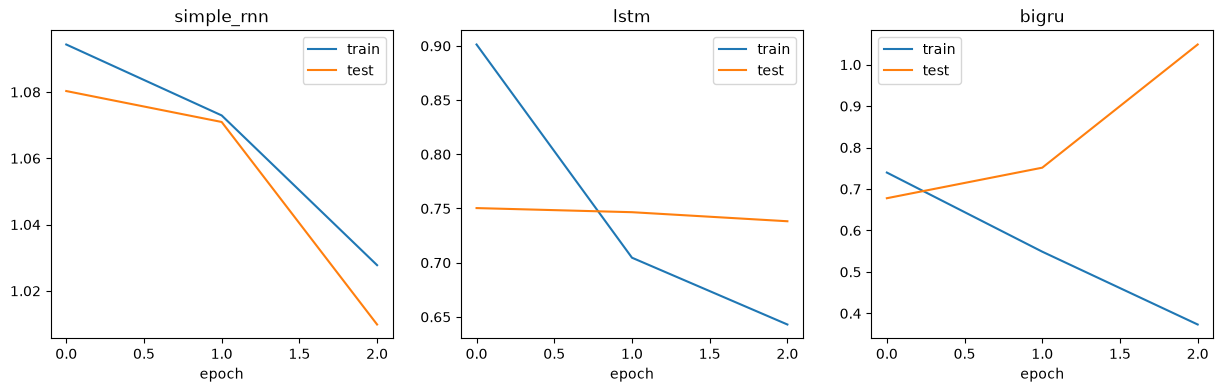

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, h) in zip(axes, histories.items()):
    ax.plot(h.history['loss'], label='train')
    ax.plot(h.history['val_loss'], label='test')
    ax.set_title(name)
    ax.set_xlabel('epoch')
    ax.legend()
plt.show()

## Results

In [7]:
best = max(scores, key=scores.get)
model = setups[best]
print(best)

y_pred = model.predict(X_test, verbose=0).argmax(1)
print(classification_report(y_test, y_pred, target_names=classes))

lstm


              precision    recall  f1-score   support

       Mixed       0.56      0.62      0.59      3333
    Negative       0.72      0.75      0.73      3333
    Positive       0.74      0.63      0.68      3334

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67      0.67     10000



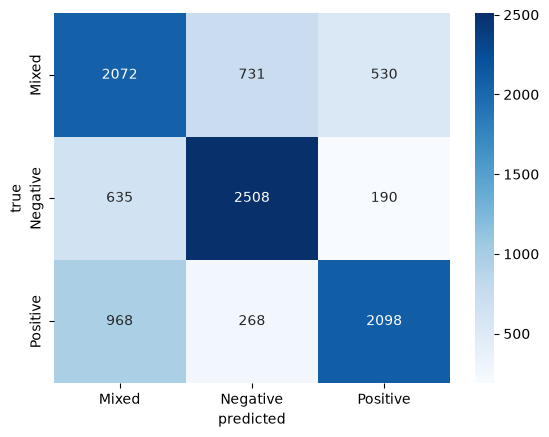

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('predicted')
plt.ylabel('true')
plt.show()

## New sentences

In [9]:
sentences = [
    'الفندق رائع جدا والموظفين محترمين والاكل لذيذ',
    'تجربة سيئة للغاية، الغرفة وسخة والخدمة بطيئة ولن اكرر الزيارة',
    'الكتاب ممتع في البداية لكن النهاية كانت مخيبة للامال',
    'المكان جميل لكن الاسعار مرتفعة جدا',
    'اسوأ رواية قرأتها في حياتي، مضيعة للوقت',
    'من افضل الكتب التي قرأتها، انصح الجميع بقراءته',
]
print(any(s in set(df['text']) for s in sentences))  # make sure none are in the dataset

preds = model.predict(vectorizer([preprocess(s) for s in sentences]), verbose=0).argmax(1)
for s, p in zip(sentences, preds):
    print(classes[p], '|', s)

False
Positive | الفندق رائع جدا والموظفين محترمين والاكل لذيذ
Negative | تجربة سيئة للغاية، الغرفة وسخة والخدمة بطيئة ولن اكرر الزيارة
Mixed | الكتاب ممتع في البداية لكن النهاية كانت مخيبة للامال
Mixed | المكان جميل لكن الاسعار مرتفعة جدا
Negative | اسوأ رواية قرأتها في حياتي، مضيعة للوقت
Positive | من افضل الكتب التي قرأتها، انصح الجميع بقراءته
